### Hyper-parameters

In [1]:
actor_num = 2 # LDA 진행하고자 하는 actor 번호
topic_num_ = 3 # topic 개수

date_ = '251218'
ver_ = 1
memo_ = 'default'
output_path = f'./action_clustering_results/{date_}_ver{ver_}_{memo_}'

import os
os.makedirs(output_path, exist_ok=True)

In [2]:
import pandas as pd
import pickle
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [3]:
# with open('./actor_clustering_results/Actor_Clustering_n_3_251212_kiwi_agglomerative_2_5yr_vec100.pkl', 'rb') as f:
with open('./actor_clustering_results_yj/actor_clustering.pkl', 'rb') as f:
    df = pickle.load(f)

print(len(df))
df.head()

41338


,src,Date,Date_YYYY,Title,Contents,re_review,tagged_review,vector,cluster
0,82cook,20251207,2025,"""장보기가 무서워요""…체감물가 급등에 소비자·소상공인 '한숨'",[URL]\n\n진짜 장보기 무섭네요\n,장보기가 무서워요 체감물가 급등에 소비자 소상공인 한숨 URL 진짜 장보기 무섭네요,"[체감, 물가, 급등, 소비자, 상공인, 한숨, 장보기]","[-0.037731368, 0.21668069, 0.20546217, 0.08354...",1
1,82cook,20251206,2025,사람은 역시 자기가 경험한 만큼 세상을 보네요.,"고등3학년 올라가는 딸.\n기숙생활하는데,,여기 글 올라온 것들 보니까 고등생활이 ...",사람은 역시 자기가 경험한 만큼 세상을 보네요 고등3학년 올라가는 딸 기숙생활하는데...,"[사람, 경험, 세상, 고등, 학년, 올라가, 기숙, 생활, 올라오, 고등, 생활,...","[-0.15933605, -0.5519116, 0.77971977, -0.30370...",1
2,82cook,20251202,2025,쿠팡 대신 사용할 수 있는 쇼핑몰 추천(추천 받습니다),1. 신선제품 새벽배송\n- 마켓컬리: 상품의 질이 좋고 트렌디한 식재료 많음\n[...,쿠팡 대신 사용할 수 있는 쇼핑몰 추천 추천 받습니다 1 신선제품 새벽배송 마켓컬리...,"[쿠팡, 대신, 사용, 쇼핑몰, 추천, 추천, 신선, 제품, 새벽, 배송, 마켓, ...","[0.070887044, -0.10709982, -0.9592662, 1.49188...",1
3,82cook,20251116,2025,장보기(쿠팡 식재료 주문) 봐주세요,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데\n일도...,장보기 쿠팡 식재료 주문 봐주세요 피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이...,"[장보기, 쿠팡, 식재료, 주문, 피곤, 이유, 배달, 시키, 카드, 나오, 건강,...","[-0.749288, 2.328057, -1.223929, 0.2562982, 0....",1
4,82cook,20251112,2025,요즘 장보기를 거의 쿠팡과 톡딜에서 해요,최근 몇 달 간 90%이상이 그럴거같아요\n마트는 근처에 홈플이 있는데 최근에 행사...,요즘 장보기를 거의 쿠팡과 톡딜에서 해요 최근 몇 달 간 90 이상이 그럴거같아요 ...,"[장보기, 쿠팡, 톡딜, 최근, 이상, 마트, 근처, 홈플, 최근, 행사, 상품, ...","[-1.254588, 0.5734759, 0.09356273, 0.54739547,...",1


In [4]:
df['tokenized'] = df['tagged_review']
df.head()

,src,Date,Date_YYYY,Title,Contents,re_review,tagged_review,vector,cluster,tokenized
0,82cook,20251207,2025,"""장보기가 무서워요""…체감물가 급등에 소비자·소상공인 '한숨'",[URL]\n\n진짜 장보기 무섭네요\n,장보기가 무서워요 체감물가 급등에 소비자 소상공인 한숨 URL 진짜 장보기 무섭네요,"[체감, 물가, 급등, 소비자, 상공인, 한숨, 장보기]","[-0.037731368, 0.21668069, 0.20546217, 0.08354...",1,"[체감, 물가, 급등, 소비자, 상공인, 한숨, 장보기]"
1,82cook,20251206,2025,사람은 역시 자기가 경험한 만큼 세상을 보네요.,"고등3학년 올라가는 딸.\n기숙생활하는데,,여기 글 올라온 것들 보니까 고등생활이 ...",사람은 역시 자기가 경험한 만큼 세상을 보네요 고등3학년 올라가는 딸 기숙생활하는데...,"[사람, 경험, 세상, 고등, 학년, 올라가, 기숙, 생활, 올라오, 고등, 생활,...","[-0.15933605, -0.5519116, 0.77971977, -0.30370...",1,"[사람, 경험, 세상, 고등, 학년, 올라가, 기숙, 생활, 올라오, 고등, 생활,..."
2,82cook,20251202,2025,쿠팡 대신 사용할 수 있는 쇼핑몰 추천(추천 받습니다),1. 신선제품 새벽배송\n- 마켓컬리: 상품의 질이 좋고 트렌디한 식재료 많음\n[...,쿠팡 대신 사용할 수 있는 쇼핑몰 추천 추천 받습니다 1 신선제품 새벽배송 마켓컬리...,"[쿠팡, 대신, 사용, 쇼핑몰, 추천, 추천, 신선, 제품, 새벽, 배송, 마켓, ...","[0.070887044, -0.10709982, -0.9592662, 1.49188...",1,"[쿠팡, 대신, 사용, 쇼핑몰, 추천, 추천, 신선, 제품, 새벽, 배송, 마켓, ..."
3,82cook,20251116,2025,장보기(쿠팡 식재료 주문) 봐주세요,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데\n일도...,장보기 쿠팡 식재료 주문 봐주세요 피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이...,"[장보기, 쿠팡, 식재료, 주문, 피곤, 이유, 배달, 시키, 카드, 나오, 건강,...","[-0.749288, 2.328057, -1.223929, 0.2562982, 0....",1,"[장보기, 쿠팡, 식재료, 주문, 피곤, 이유, 배달, 시키, 카드, 나오, 건강,..."
4,82cook,20251112,2025,요즘 장보기를 거의 쿠팡과 톡딜에서 해요,최근 몇 달 간 90%이상이 그럴거같아요\n마트는 근처에 홈플이 있는데 최근에 행사...,요즘 장보기를 거의 쿠팡과 톡딜에서 해요 최근 몇 달 간 90 이상이 그럴거같아요 ...,"[장보기, 쿠팡, 톡딜, 최근, 이상, 마트, 근처, 홈플, 최근, 행사, 상품, ...","[-1.254588, 0.5734759, 0.09356273, 0.54739547,...",1,"[장보기, 쿠팡, 톡딜, 최근, 이상, 마트, 근처, 홈플, 최근, 행사, 상품, ..."


# ◆ 1. LDA를 위한 데이터 전처리
* 1.1. 전체 단어의 사전 만들고 각 문서에 매칭하기
    > 단어들이 문서에 얼마나 위치해 있는지 분포를 파악해야하기 때문에 분석할 전체 데이터 대상으로
    사용된 단어의 사전을 생성해야한다,


In [5]:
import gensim
from gensim import corpora, models
from gensim.corpora import Dictionary

### 1.1 전체 단어의 사전 만들고 각 문서에 매칭하기

In [6]:
# cluster 0
df_cluster0 = df[df['cluster'] == actor_num]
print(len(df_cluster0))
df_cluster0.head(5)

1531


,src,Date,Date_YYYY,Title,Contents,re_review,tagged_review,vector,cluster,tokenized
280,블라인드,20241810,2024,카카오 장보기 배송 시간 관련..,안녕하세요.\n어디 올리는데가 없어 여기 써봅니다ㅠㅠ\n관리하시는 분들이 어디 소속...,카카오 장보기 배송 시간 관련 안녕하세요 어디 올리는데가 없어 여기 써봅니다 관리하...,"[카카오, 장보기, 배송, 시간, 관련, 안녕, 올리, 관리, 소속, 모르, 평소,...","[0.67235506, -1.97095, 0.49461392, 1.0657344, ...",2,"[카카오, 장보기, 배송, 시간, 관련, 안녕, 올리, 관리, 소속, 모르, 평소,..."
1040,블라인드,20242410,2024,흑백요리사에 나온 사람들 식당 몇군데 가본 후기.,▪︎적은 순서가 좋았던 순위는 아님. 먼저 생각나는 순으로 적음.\n\n1. 모수 ...,흑백요리사에 나온 사람들 식당 몇군데 가본 후기 적은 순서가 좋았던 순위는 아님 먼...,"[흑백, 요리사, 나오, 사람, 식당, 후기, 순서, 순위, 생각나, 모수, 안성,...","[-1.6821477, 0.09765564, 3.9834487, 0.666747, ...",2,"[흑백, 요리사, 나오, 사람, 식당, 후기, 순서, 순위, 생각나, 모수, 안성,..."
1148,블라인드,20242102,2024,스시 오마카세 추천,요즘 많은 사람들이 스시 오마카세를 즐기고 있는 것 같아.\n\n그래서 알고 있는 ...,스시 오마카세 추천 요즘 많은 사람들이 스시 오마카세를 즐기고 있는 것 같아 그래서...,"[스시, 오마카세, 추천, 사람, 스시, 오마카세, 즐기, 식당, 추천, 요즘, 사...","[-3.0526645, -0.8221522, 0.76234794, -1.609574...",2,"[스시, 오마카세, 추천, 사람, 스시, 오마카세, 즐기, 식당, 추천, 요즘, 사..."
1208,블라인드,20242109,2024,거제 로컬 맛집;-),거제 여행 오는 분들!\n관광ㅈㅣ음식이 지겹다면 이건 어떤지...\n\n✔️한식\n...,거제 로컬 맛집 거제 여행 오는 분들 관광 음식이 지겹다면 이건 어떤지 한식 옥포 ...,"[거제, 로컬, 맛집, 거제, 여행, 관광, 음식, 한식, 옥포, 나영밀, 작업실,...","[0.9221846, 1.4458159, 1.5122179, -0.95887005,...",2,"[거제, 로컬, 맛집, 거제, 여행, 관광, 음식, 한식, 옥포, 나영밀, 작업실,..."
1221,블라인드,20250905,2025,노량진 수산시장 다녀왔습니다.,"전어 가격이 어제 1kg 당 4만원 하던게,\n새벽에 갑자기 물량 터지면서 키로 당...",노량진 수산시장 다녀왔습니다 전어 가격이 어제 1kg 당 4만원 하던게 새벽에 갑자...,"[노량진, 수산, 시장, 다녀오, 전어, 가격, 어제, 새벽, 물량, 터지, 내려오...","[-1.6655338, 0.72536564, 1.4996424, -0.1748472...",2,"[노량진, 수산, 시장, 다녀오, 전어, 가격, 어제, 새벽, 물량, 터지, 내려오..."


In [7]:
all_documents = list(df_cluster0['tokenized'])
dictionary = Dictionary(all_documents)
dictionary.token2id

{'가격': 0,
 '가지': 1,
 '개념': 2,
 '걱정': 3,
 '고객': 4,
 '고르': 5,
 '관련': 6,
 '관리': 7,
 '구매': 8,
 '기다리': 9,
 '기사': 10,
 '놀라': 11,
 '마감': 12,
 '모르': 13,
 '무리': 14,
 '물건': 15,
 '밀리': 16,
 '배송': 17,
 '불만': 18,
 '사용': 19,
 '생기': 20,
 '선택': 21,
 '소속': 22,
 '시간': 23,
 '안녕': 24,
 '올리': 25,
 '요청': 26,
 '이마트': 27,
 '이유': 28,
 '인원': 29,
 '장보': 30,
 '장보기': 31,
 '정해진': 32,
 '졸리': 33,
 '좋아하': 34,
 '주문': 35,
 '즐기': 36,
 '지정': 37,
 '지키': 38,
 '초과': 39,
 '카카오': 40,
 '평소': 41,
 '하소연': 42,
 '힘들': 43,
 '가게': 44,
 '가격대': 45,
 '감안': 46,
 '개미': 47,
 '개비추': 48,
 '고급': 49,
 '고유': 50,
 '고전': 51,
 '과거': 52,
 '그리': 53,
 '그림': 54,
 '기대': 55,
 '기수': 56,
 '기억': 57,
 '나오': 58,
 '네오': 59,
 '느낌': 60,
 '다이닝': 61,
 '당시': 62,
 '대비': 63,
 '디쉬': 64,
 '떨어지': 65,
 '레몬': 66,
 '레스토랑': 67,
 '맛있': 68,
 '메뉴판': 69,
 '모수': 70,
 '무난하': 71,
 '밀도': 72,
 '방문': 73,
 '방향': 74,
 '백수': 75,
 '백수저': 76,
 '보이': 77,
 '본연': 78,
 '부르': 79,
 '비례': 80,
 '비빔': 81,
 '비슷하': 82,
 '비싸': 83,
 '비채나': 84,
 '사람': 85,
 '상견례': 86,
 '생각': 87,
 '생각나': 88,
 '서비스': 89,

In [8]:
corpus = []
for doc in all_documents:
    corpus.append(dictionary.doc2bow(doc))
    
corpus

[[(0, 2),
  (1, 1),
  (2, 1),
  (3, 1),
  (4, 1),
  (5, 1),
  (6, 1),
  (7, 1),
  (8, 1),
  (9, 3),
  (10, 2),
  (11, 1),
  (12, 1),
  (13, 2),
  (14, 2),
  (15, 1),
  (16, 1),
  (17, 6),
  (18, 2),
  (19, 1),
  (20, 1),
  (21, 1),
  (22, 1),
  (23, 5),
  (24, 1),
  (25, 1),
  (26, 1),
  (27, 1),
  (28, 1),
  (29, 1),
  (30, 1),
  (31, 2),
  (32, 1),
  (33, 2),
  (34, 1),
  (35, 4),
  (36, 1),
  (37, 1),
  (38, 1),
  (39, 1),
  (40, 2),
  (41, 1),
  (42, 1),
  (43, 1)],
 [(0, 3),
  (13, 2),
  (35, 2),
  (36, 2),
  (43, 2),
  (44, 1),
  (45, 1),
  (46, 1),
  (47, 2),
  (48, 1),
  (49, 1),
  (50, 1),
  (51, 1),
  (52, 1),
  (53, 1),
  (54, 1),
  (55, 1),
  (56, 1),
  (57, 2),
  (58, 1),
  (59, 1),
  (60, 4),
  (61, 5),
  (62, 1),
  (63, 2),
  (64, 2),
  (65, 1),
  (66, 1),
  (67, 1),
  (68, 5),
  (69, 1),
  (70, 1),
  (71, 1),
  (72, 1),
  (73, 1),
  (74, 1),
  (75, 4),
  (76, 2),
  (77, 1),
  (78, 1),
  (79, 1),
  (80, 1),
  (81, 2),
  (82, 1),
  (83, 1),
  (84, 1),
  (85, 4),
  (86, 1)

# ◆ 2. LDA모델 만들기
* 2.1 LDA 기본 모델 만들기
* 2.2 LDA 토픽개수 선정
* 2.3 선정한 토픽 개수로 Action 넘버 매칭

### 2.1 LDA 기본 모델 만들기

In [9]:
# topic_num = 4 # 3 
# ldamodel = gensim.models.ldamodel.LdaModel(corpus,
#                                            num_topics= topic_num,
#                                            id2word= dictionary,
#                                            passes= 20,
#                                            iterations= 50,
#                                            random_state= 42)

In [10]:
# ldamodel.print_topics(num_words= 10)

In [11]:
# for i in range(int(len(corpus)/100)):
#     print(ldamodel.get_document_topics(corpus[i]))

### 2.2 LDA 토픽 수 선정
* cohearence & perplexcity

In [12]:
from gensim.models import CoherenceModel # coherence 모델 라이브러리
import matplotlib.pyplot as plt # 그래프 그리기
import numpy as np

> 2.2.1 Perplexity 그래프 만들기

In [13]:
perplexity_values = []

for i in range(2, 10):
    ldamodel = gensim.models.ldamodel.LdaModel(corpus,
                                               num_topics= i,
                                               id2word= dictionary)
    perplexity_v = np.exp(-ldamodel.log_perplexity(corpus))
    perplexity_values.append(perplexity_v)

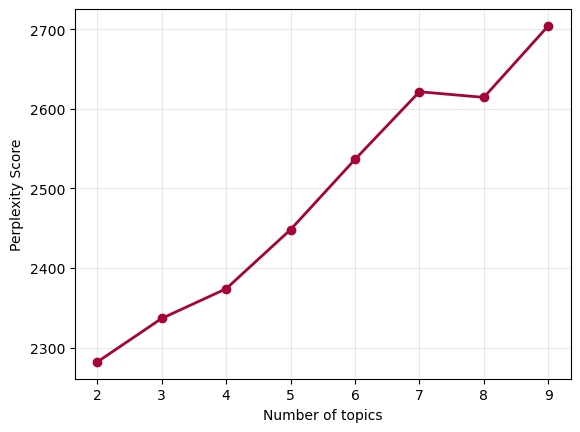

In [35]:
x = range(2, 10)

plt.plot(
    x,
    perplexity_values,
    marker='o',          # 원형 점
    color='#A50534',     # 지정한 색상
    linewidth=2
)

plt.xlabel('Number of topics')
plt.ylabel('Perplexity Score')
plt.grid(alpha=0.3)      # (선택) 가독성용
plt.gca().set_facecolor('none')
plt.gcf().set_facecolor('none')
plt.savefig(f'{output_path}/{date_}_{ver_}_{memo_}_Actor{actor_num}_action_cluster_perplexity_plot.png', dpi=300, transparent=True)
# plt.show()

In [15]:
# perplexity 그래프 raw 데이터 저장
result0 = pd.DataFrame([x, perplexity_values]).T
result0.columns = ['n_cluster', 'perplexity_values']
result0.to_excel(f'{output_path}/{date_}_{ver_}_{memo_}_Actor{actor_num}_action_cluster_perplexity.xlsx', index=False)

> 2.2.1 Coherence 그래프 만들기

In [16]:
coherence_values = []
top_n = 3

for i in tqdm(range(2,10)):
    ldamodel = gensim.models.ldamodel.LdaModel(corpus,
                                               num_topics= i,
                                               id2word= dictionary)
    coherence_model = CoherenceModel(model= ldamodel,
                                 texts= all_documents,
                                 dictionary= dictionary,
                                 topn= top_n)
    
    coherence_score = coherence_model.get_coherence()
    coherence_values.append(coherence_score)

100%|██████████| 8/8 [00:25<00:00,  3.24s/it]


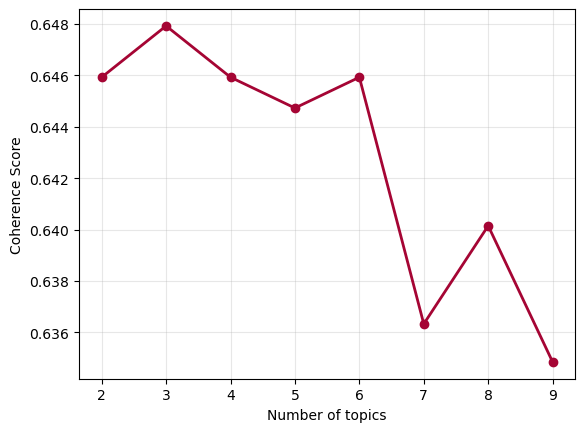

In [36]:
x = range(2, 10)

plt.plot(
    x,
    coherence_values,
    marker='o',          # 원형 점
    color='#A50534',     # 지정한 색상
    linewidth=2
)

plt.xlabel('Number of topics')
plt.ylabel('Coherence Score')
plt.grid(alpha=0.3)      # (선택) 가독성용
plt.gca().set_facecolor('none')
plt.gcf().set_facecolor('none')
plt.savefig(f'{output_path}/{date_}_{ver_}_{memo_}_Actor{actor_num}_action_cluster_coherance_plot.png', dpi=300, transparent=True)
# plt.show()

In [18]:
# Coherance 그래프 raw 데이터 저장
result0 = pd.DataFrame([x, coherence_values]).T
result0.columns = ['n_cluster', 'coherence_values']
result0.to_excel(f'{output_path}/{date_}_{ver_}_{memo_}_Actor{actor_num}_action_cluster_coherence.xlsx', index=False)

### 2.3 선정한 토픽 개수로 Action 넘버 매칭

In [19]:
topic_num = topic_num_ # 3

ldamodel = gensim.models.ldamodel.LdaModel(corpus,
                                           num_topics= topic_num,
                                           id2word= dictionary,
                                           passes= 20,
                                           iterations= 50,
                                           random_state= 42)

In [20]:
ldamodel.get_document_topics(corpus)[2]

[(2, 0.9953676)]

In [21]:
action_align = []

for doc in tqdm(ldamodel.get_document_topics(corpus)):
    label = []
    value = []
    
    for score in doc:
        label.append(score[0])
        value.append(score[1])
        
    max_index = np.argmax(value)
    action_n = label[max_index]
    action_align.append(action_n)
    

100%|██████████| 1531/1531 [00:00<00:00, 3156.04it/s]


In [22]:
df_cluster0['action_cluster'] = action_align
df_cluster0.head()

,src,Date,Date_YYYY,Title,Contents,re_review,tagged_review,vector,cluster,tokenized,action_cluster
280,블라인드,20241810,2024,카카오 장보기 배송 시간 관련..,안녕하세요.\n어디 올리는데가 없어 여기 써봅니다ㅠㅠ\n관리하시는 분들이 어디 소속...,카카오 장보기 배송 시간 관련 안녕하세요 어디 올리는데가 없어 여기 써봅니다 관리하...,"[카카오, 장보기, 배송, 시간, 관련, 안녕, 올리, 관리, 소속, 모르, 평소,...","[0.67235506, -1.97095, 0.49461392, 1.0657344, ...",2,"[카카오, 장보기, 배송, 시간, 관련, 안녕, 올리, 관리, 소속, 모르, 평소,...",0
1040,블라인드,20242410,2024,흑백요리사에 나온 사람들 식당 몇군데 가본 후기.,▪︎적은 순서가 좋았던 순위는 아님. 먼저 생각나는 순으로 적음.\n\n1. 모수 ...,흑백요리사에 나온 사람들 식당 몇군데 가본 후기 적은 순서가 좋았던 순위는 아님 먼...,"[흑백, 요리사, 나오, 사람, 식당, 후기, 순서, 순위, 생각나, 모수, 안성,...","[-1.6821477, 0.09765564, 3.9834487, 0.666747, ...",2,"[흑백, 요리사, 나오, 사람, 식당, 후기, 순서, 순위, 생각나, 모수, 안성,...",1
1148,블라인드,20242102,2024,스시 오마카세 추천,요즘 많은 사람들이 스시 오마카세를 즐기고 있는 것 같아.\n\n그래서 알고 있는 ...,스시 오마카세 추천 요즘 많은 사람들이 스시 오마카세를 즐기고 있는 것 같아 그래서...,"[스시, 오마카세, 추천, 사람, 스시, 오마카세, 즐기, 식당, 추천, 요즘, 사...","[-3.0526645, -0.8221522, 0.76234794, -1.609574...",2,"[스시, 오마카세, 추천, 사람, 스시, 오마카세, 즐기, 식당, 추천, 요즘, 사...",2
1208,블라인드,20242109,2024,거제 로컬 맛집;-),거제 여행 오는 분들!\n관광ㅈㅣ음식이 지겹다면 이건 어떤지...\n\n✔️한식\n...,거제 로컬 맛집 거제 여행 오는 분들 관광 음식이 지겹다면 이건 어떤지 한식 옥포 ...,"[거제, 로컬, 맛집, 거제, 여행, 관광, 음식, 한식, 옥포, 나영밀, 작업실,...","[0.9221846, 1.4458159, 1.5122179, -0.95887005,...",2,"[거제, 로컬, 맛집, 거제, 여행, 관광, 음식, 한식, 옥포, 나영밀, 작업실,...",2
1221,블라인드,20250905,2025,노량진 수산시장 다녀왔습니다.,"전어 가격이 어제 1kg 당 4만원 하던게,\n새벽에 갑자기 물량 터지면서 키로 당...",노량진 수산시장 다녀왔습니다 전어 가격이 어제 1kg 당 4만원 하던게 새벽에 갑자...,"[노량진, 수산, 시장, 다녀오, 전어, 가격, 어제, 새벽, 물량, 터지, 내려오...","[-1.6655338, 0.72536564, 1.4996424, -0.1748472...",2,"[노량진, 수산, 시장, 다녀오, 전어, 가격, 어제, 새벽, 물량, 터지, 내려오...",0


In [23]:
df_cluster0['action_cluster'].value_counts()

action_cluster
2    668
1    450
0    413
Name: count, dtype: int64

# ◆ 3. LDA 시각화 (LDAvis)


In [24]:
# !pip install pyLDAvis

In [25]:
#경고무시
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

#LDA 시각화 라이브러리
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

In [26]:
prepared_data = gensimvis.prepare(ldamodel, corpus, dictionary)
pyLDAvis.save_html(prepared_data, f'{output_path}/ldavis_Actor_{actor_num}.html')
# pyLDAvis.display(prepared_data)

In [27]:
pyLDAvis.display(prepared_data)

# ◆ 4. LDA 분석을 위한 후작업
* LDAvis와 LDA모델의 토픽 넘버 매칭
* LDAvis 결과와 LDA모델의 결과를 보고 직접 매칭해야한다.

In [28]:
topics = ldamodel.show_topics(num_topics= -1, # - 1 은 다 가져오라는것
                              formatted= True,
                              )

for topic_id, topic_desc in topics :
    print(f"Topic ID : {topic_id}, Description : {topic_desc}")

Topic ID : 0, Description : 0.011*"펜션" + 0.009*"아이" + 0.008*"준비" + 0.007*"요리" + 0.007*"음식" + 0.007*"가족" + 0.006*"일산" + 0.006*"맛있" + 0.006*"예약" + 0.005*"식사"
Topic ID : 1, Description : 0.030*"고기" + 0.023*"맛집" + 0.018*"맛있" + 0.010*"나오" + 0.009*"갈비" + 0.009*"주문" + 0.009*"한우" + 0.007*"메뉴" + 0.007*"식사" + 0.006*"돼지"
Topic ID : 2, Description : 0.029*"맛집" + 0.018*"맛있" + 0.014*"나오" + 0.009*"메뉴" + 0.008*"음식" + 0.007*"식사" + 0.007*"주문" + 0.006*"즐기" + 0.006*"느끼" + 0.006*"구이"


In [29]:
# 모델 LDAvis
# lda   ldavis
# 0     3
# 1     1
# 2     2

In [30]:
new_action_topic = []

for i in df_cluster0['action_cluster'] :
    if i == 0 :
        n = 3
    elif i == 1 : 
        n = 1
    elif i == 2 :
        n = 2
    # else : 
    #     n = 1
    new_action_topic.append(n)

In [31]:
df_cluster0['action_cluster'] = new_action_topic
df_cluster0.head()

,src,Date,Date_YYYY,Title,Contents,re_review,tagged_review,vector,cluster,tokenized,action_cluster
280,블라인드,20241810,2024,카카오 장보기 배송 시간 관련..,안녕하세요.\n어디 올리는데가 없어 여기 써봅니다ㅠㅠ\n관리하시는 분들이 어디 소속...,카카오 장보기 배송 시간 관련 안녕하세요 어디 올리는데가 없어 여기 써봅니다 관리하...,"[카카오, 장보기, 배송, 시간, 관련, 안녕, 올리, 관리, 소속, 모르, 평소,...","[0.67235506, -1.97095, 0.49461392, 1.0657344, ...",2,"[카카오, 장보기, 배송, 시간, 관련, 안녕, 올리, 관리, 소속, 모르, 평소,...",3
1040,블라인드,20242410,2024,흑백요리사에 나온 사람들 식당 몇군데 가본 후기.,▪︎적은 순서가 좋았던 순위는 아님. 먼저 생각나는 순으로 적음.\n\n1. 모수 ...,흑백요리사에 나온 사람들 식당 몇군데 가본 후기 적은 순서가 좋았던 순위는 아님 먼...,"[흑백, 요리사, 나오, 사람, 식당, 후기, 순서, 순위, 생각나, 모수, 안성,...","[-1.6821477, 0.09765564, 3.9834487, 0.666747, ...",2,"[흑백, 요리사, 나오, 사람, 식당, 후기, 순서, 순위, 생각나, 모수, 안성,...",1
1148,블라인드,20242102,2024,스시 오마카세 추천,요즘 많은 사람들이 스시 오마카세를 즐기고 있는 것 같아.\n\n그래서 알고 있는 ...,스시 오마카세 추천 요즘 많은 사람들이 스시 오마카세를 즐기고 있는 것 같아 그래서...,"[스시, 오마카세, 추천, 사람, 스시, 오마카세, 즐기, 식당, 추천, 요즘, 사...","[-3.0526645, -0.8221522, 0.76234794, -1.609574...",2,"[스시, 오마카세, 추천, 사람, 스시, 오마카세, 즐기, 식당, 추천, 요즘, 사...",2
1208,블라인드,20242109,2024,거제 로컬 맛집;-),거제 여행 오는 분들!\n관광ㅈㅣ음식이 지겹다면 이건 어떤지...\n\n✔️한식\n...,거제 로컬 맛집 거제 여행 오는 분들 관광 음식이 지겹다면 이건 어떤지 한식 옥포 ...,"[거제, 로컬, 맛집, 거제, 여행, 관광, 음식, 한식, 옥포, 나영밀, 작업실,...","[0.9221846, 1.4458159, 1.5122179, -0.95887005,...",2,"[거제, 로컬, 맛집, 거제, 여행, 관광, 음식, 한식, 옥포, 나영밀, 작업실,...",2
1221,블라인드,20250905,2025,노량진 수산시장 다녀왔습니다.,"전어 가격이 어제 1kg 당 4만원 하던게,\n새벽에 갑자기 물량 터지면서 키로 당...",노량진 수산시장 다녀왔습니다 전어 가격이 어제 1kg 당 4만원 하던게 새벽에 갑자...,"[노량진, 수산, 시장, 다녀오, 전어, 가격, 어제, 새벽, 물량, 터지, 내려오...","[-1.6655338, 0.72536564, 1.4996424, -0.1748472...",2,"[노량진, 수산, 시장, 다녀오, 전어, 가격, 어제, 새벽, 물량, 터지, 내려오...",3


In [32]:
# df_cluster0 = df_cluster0[['Review', 'tagged_review', 'cluster', 'action_cluster']]

In [33]:
# csv 저장
df_cluster0.to_csv(f'{output_path}/Actor{actor_num}_action_cluster.csv', encoding='utf-8-sig')

# pkl 저장
with open (f'{output_path}/Actor{actor_num}_action_cluster.pkl', 'wb') as f:
    pickle.dump(df_cluster0, f)

In [34]:
df_cluster0['action_cluster'].value_counts()

action_cluster
2    668
1    450
3    413
Name: count, dtype: int64